In [31]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import sys
import warnings
%matplotlib inline
plt.rc('font',size=13)
warnings.filterwarnings('ignore')

In [32]:
# 读取数据
trn_click=pd.read_csv('./data/train_click_log.csv')
item_df=pd.read_csv('./data/articles.csv')
item_df=item_df.rename(columns={'article_id':'click_article_id'})
item_emb_df=pd.read_csv('./data/articles_emb.csv')

tst_click=pd.read_csv('./data/testA_click_log.csv')

train_click_log.csv文件数据中每个字段的含义:

user_id: 用户的唯一标识

click_article_id: 用户点击的文章唯一标识

click_timestamp: 用户点击文章时的时间戳

click_environment: 用户点击文章的环境

click_deviceGroup: 用户点击文章的设备组

click_os: 用户点击文章时的操作系统

click_country: 用户点击文章时的所在的国家

click_region: 用户点击文章时所在的区域

click_referrer_type: 用户点击文章时，文章的来源

In [33]:
trn_click.tail()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
1112618,33446,16346,1508212054157,4,3,2,1,25,1
1112619,0,30760,1508211672520,4,1,17,1,25,2
1112620,0,157507,1508211702520,4,1,17,1,25,2
1112621,199178,234481,1508211513583,4,3,2,1,25,2
1112622,199178,233578,1508211543583,4,3,2,1,25,2


In [34]:
# 计算用户点击的rank
trn_click['rank']=trn_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)
tst_click['rank']=tst_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)

In [35]:
# 计算用户的点击次数,transform做分组运算，返回结果原原DataFrame得行数一致
trn_click['click_cnts']=trn_click.groupby(['user_id'])['click_timestamp'].transform('count')
tst_click['click_cnts']=tst_click.groupby(['user_id'])['click_timestamp'].transform('count')

In [36]:
item_df.head()

,click_article_id,category_id,created_at_ts,words_count
0,0,0,1513144419000,168
1,1,1,1405341936000,189
2,2,1,1408667706000,250
3,3,1,1408468313000,230
4,4,1,1407071171000,162


训练集用户点击日志

In [37]:
# merge连接两张表，how指定连接类型，left保留左表全部，右表能匹配则不起
trn_click=trn_click.merge(item_df,how='left',on=['click_article_id'])
trn_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,199999,160417,1507029570190,4,1,17,1,13,1,11,11,281,1506942089000,173
1,199999,5408,1507029571478,4,1,17,1,13,1,10,11,4,1506994257000,118
2,199999,50823,1507029601478,4,1,17,1,13,1,9,11,99,1507013614000,213
3,199998,157770,1507029532200,4,1,17,1,25,5,40,40,281,1506983935000,201
4,199998,96613,1507029671831,4,1,17,1,25,5,39,40,209,1506938444000,185


In [38]:
trn_click.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1112623 entries, 0 to 1112622
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   user_id              1112623 non-null  int64
 1   click_article_id     1112623 non-null  int64
 2   click_timestamp      1112623 non-null  int64
 3   click_environment    1112623 non-null  int64
 4   click_deviceGroup    1112623 non-null  int64
 5   click_os             1112623 non-null  int64
 6   click_country        1112623 non-null  int64
 7   click_region         1112623 non-null  int64
 8   click_referrer_type  1112623 non-null  int64
 9   rank                 1112623 non-null  int32
 10  click_cnts           1112623 non-null  int64
 11  category_id          1112623 non-null  int64
 12  created_at_ts        1112623 non-null  int64
 13  words_count          1112623 non-null  int64
dtypes: int32(1), int64(13)
memory usage: 114.6 MB


In [45]:
trn_click.describe()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
count,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06,1.112623e+06
mean,1.221198e+05,1.951541e+05,1.507588e+12,3.947786e+00,1.815981e+00,1.301976e+01,1.310776e+00,1.813587e+01,1.910063e+00,7.118518e+00,1.323704e+01,3.056176e+02,1.506598e+12,2.011981e+02
std,5.540349e+04,9.292286e+04,3.363466e+08,3.276715e-01,1.035170e+00,6.967844e+00,1.618264e+00,7.105832e+00,1.220012e+00,1.016095e+01,1.631503e+01,1.155791e+02,8.343066e+09,5.223881e+01
min,0.000000e+00,3.000000e+00,1.507030e+12,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.166573e+12,0.000000e+00
25%,7.934700e+04,1.239090e+05,1.507297e+12,4.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.300000e+01,1.000000e+00,2.000000e+00,4.000000e+00,2.500000e+02,1.507220e+12,1.700000e+02
50%,1.309670e+05,2.038900e+05,1.507596e+12,4.000000e+00,1.000000e+00,1.700000e+01,1.000000e+00,2.100000e+01,2.000000e+00,4.000000e+00,8.000000e+00,3.280000e+02,1.507553e+12,1.970000e+02
75%,1.704010e+05,2.777120e+05,1.507841e+12,4.000000e+00,3.000000e+00,1.700000e+01,1.000000e+00,2.500000e+01,2.000000e+00,8.000000e+00,1.600000e+01,4.100000e+02,1.507756e+12,2.280000e+02
max,1.999990e+05,3.640460e+05,1.510603e+12,4.000000e+00,5.000000e+00,2.000000e+01,1.100000e+01,2.800000e+01,7.000000e+00,2.410000e+02,2.410000e+02,4.600000e+02,1.510666e+12,6.690000e+03


In [39]:
# 一共有20w用户
trn_click.user_id.nunique()

200000

In [40]:
# 每个用户至少点击过两次
trn_click.groupby('user_id')['click_article_id'].count().min()

2

In [41]:
trn_click['click_referrer_type'].value_counts().reset_index()

,click_referrer_type,count
0,2,606358
1,1,418414
2,5,41238
3,7,26603
4,6,10932
5,4,8813
6,3,265


绘制直方图看一下基本的属性分布

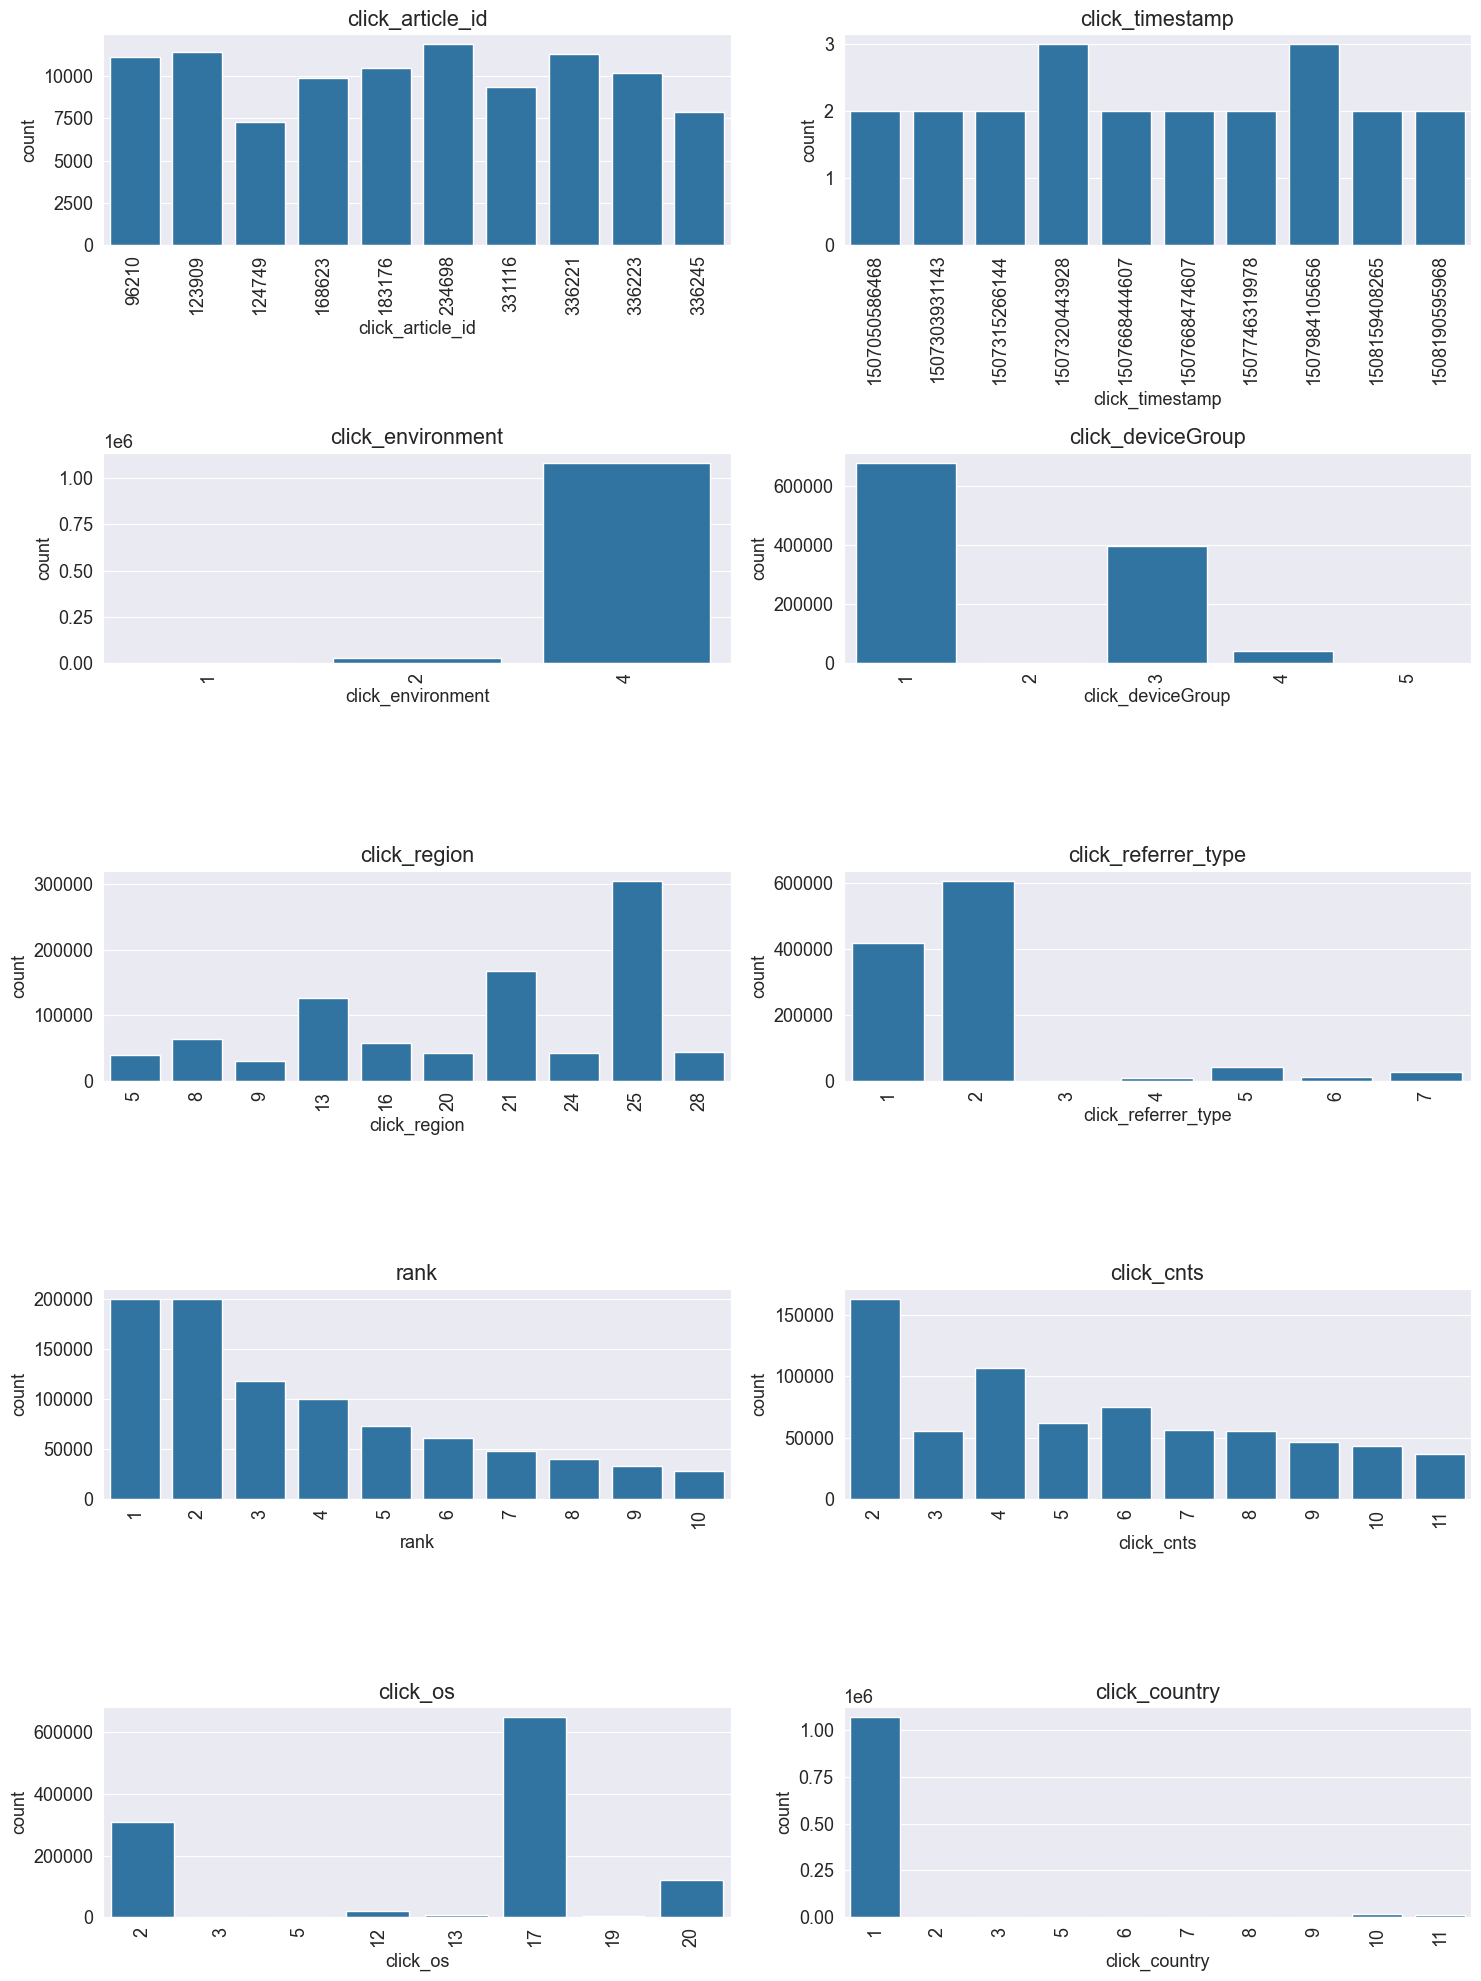

In [43]:
plt.figure(figsize=(15,20))
i=1
for col in ['click_article_id','click_timestamp','click_environment','click_deviceGroup','click_region','click_referrer_type','rank','click_cnts','click_os','click_country']:
    plt_envs=plt.subplot(5,2,i)
    i+=1
    # value_counts返回series，用reset_index变成Dataframe方便后续索引
    v=trn_click[col].value_counts().reset_index()[:10]
    fig=sns.barplot(x=v.iloc[:,0],y=v.iloc[:,1])
    for item in fig.get_xticklabels():
        item.set_rotation(90)
    plt.title(col)
plt.tight_layout()
plt.show()

测试集用户点击日志

In [44]:
tst_click=tst_click.merge(item_df,how='left',on=['click_article_id'])
tst_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,249999,160974,1506959142820,4,1,17,1,13,2,19,19,281,1506912747000,259
1,249999,160417,1506959172820,4,1,17,1,13,2,18,19,281,1506942089000,173
2,249998,160974,1506959056066,4,1,12,1,13,2,5,5,281,1506912747000,259
3,249998,202557,1506959086066,4,1,12,1,13,2,4,5,327,1506938401000,219
4,249997,183665,1506959088613,4,1,17,1,15,5,7,7,301,1500895686000,256


In [46]:
tst_click.describe()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
count,518010.000000,518010.000000,5.180100e+05,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,518010.000000,5.180100e+05,518010.000000
mean,227342.428169,193803.792550,1.507387e+12,3.947300,1.738285,13.628467,1.348209,18.250250,1.819614,15.521785,30.043586,305.324961,1.506883e+12,210.966331
std,14613.907188,88279.388177,3.706127e+08,0.323916,1.020858,6.625564,1.703524,7.060798,1.082657,33.957702,56.868021,110.411513,5.816668e+09,83.040065
min,200000.000000,137.000000,1.506959e+12,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.265812e+12,0.000000
25%,214926.000000,128551.000000,1.507026e+12,4.000000,1.000000,12.000000,1.000000,13.000000,1.000000,4.000000,10.000000,252.000000,1.506970e+12,176.000000
50%,229109.000000,199197.000000,1.507308e+12,4.000000,1.000000,17.000000,1.000000,21.000000,2.000000,8.000000,19.000000,323.000000,1.507249e+12,199.000000
75%,240182.000000,272143.000000,1.507666e+12,4.000000,3.000000,17.000000,1.000000,25.000000,2.000000,18.000000,35.000000,399.000000,1.507630e+12,232.000000
max,249999.000000,364043.000000,1.508832e+12,4.000000,5.000000,20.000000,11.000000,28.000000,7.000000,938.000000,938.000000,460.000000,1.509949e+12,3082.000000


观察到，测试集和训练集的用户不同，因此不能使用基于用户的协同过滤

新闻文章信息数据表

In [47]:
item_df.head()

,click_article_id,category_id,created_at_ts,words_count
0,0,0,1513144419000,168
1,1,1,1405341936000,189
2,2,1,1408667706000,250
3,3,1,1408468313000,230
4,4,1,1407071171000,162


In [48]:
item_df['words_count']

0         168
1         189
2         250
3         230
4         162
         ... 
364042    144
364043    463
364044    177
364045    126
364046    479
Name: words_count, Length: 364047, dtype: int64

<Axes: >

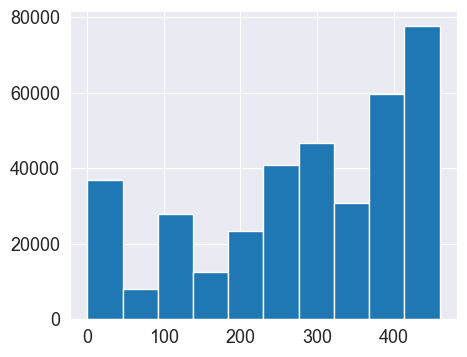

In [50]:
item_df['category_id'].hist(figsize=(5,4))

分析用户重复点点击

In [51]:
user_click_merge=pd.concat([trn_click,tst_click])

In [57]:
# agg返回按照分组的聚合结果
user_click_count=user_click_merge.groupby(['user_id','click_article_id'])['click_timestamp'].agg({'count'}).reset_index()

In [58]:
user_click_count[user_click_count['count']>7]

,user_id,click_article_id,count
311242,86295,74254,10
311243,86295,76268,10
393761,103237,205948,10
393763,103237,235689,10
576902,134850,69463,13


In [59]:
user_click_count['count'].unique()

array([ 1,  2,  4,  3,  6,  5, 10,  7, 13], dtype=int64)

In [60]:
user_click_count['count'].value_counts()

count
1     1605541
2       11621
3         422
4          77
5          26
6          12
10          4
7           3
13          1
Name: count, dtype: int64